In [3]:
pip install torch datasets pandas

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from datasets import load_dataset
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================================================
# DATA
# =========================================================

dataset = load_dataset("ag_news")

train_data = dataset["train"]
test_data = dataset["test"]

# =========================================================
# TOKENIZER
# =========================================================

def tokenize(text):
    return text.lower().split()

# =========================================================
# VOCAB
# =========================================================

counter = Counter()

for sample in train_data:
    counter.update(tokenize(sample["text"]))

vocab = {"<pad>": 0, "<unk>": 1}

for word, freq in counter.items():
    if freq >= 5:
        vocab[word] = len(vocab)

vocab_size = len(vocab)

# =========================================================
# ENCODING
# =========================================================

max_len = 40

def encode_text(text):

    tokens = tokenize(text)

    ids = [vocab.get(token, 1) for token in tokens[:max_len]]

    if len(ids) < max_len:
        ids += [0] * (max_len - len(ids))

    return torch.tensor(ids)

# =========================================================
# DATASET
# =========================================================

class AGNewsDataset(torch.utils.data.Dataset):

    def __init__(self, split):
        self.data = split

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return encode_text(self.data[idx]["text"]), self.data[idx]["label"]

train_dataset = AGNewsDataset(train_data)
test_dataset = AGNewsDataset(test_data)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

# =========================================================
# SURROGATE GRADIENT
# =========================================================

class SpikeFunction(torch.autograd.Function):

    @staticmethod
    def forward(ctx, mem, threshold):
        ctx.save_for_backward(mem)
        return (mem >= threshold).float()

    @staticmethod
    def backward(ctx, grad_output):
        mem, = ctx.saved_tensors
        surrogate = torch.clamp(1 - torch.abs(mem), min=0)
        return grad_output * surrogate, None

# =========================================================
# LIF
# =========================================================

class LIFLayer(nn.Module):

    def __init__(self, input_size, output_size, threshold=1.0):
        super().__init__()
        self.fc = nn.Linear(input_size, output_size)
        self.threshold = threshold

    def forward(self, x, mem):

        mem = 0.9 * mem + self.fc(x)

        spike = SpikeFunction.apply(mem, self.threshold)

        mem = mem * (1 - spike)

        return spike, mem

# =========================================================
# MSF
# =========================================================

class MSFLayer(nn.Module):

    def __init__(self, input_size, output_size, D=3):
        super().__init__()
        self.fc = nn.Linear(input_size, output_size)
        self.thresholds = torch.arange(1, D + 1).float().to(device)

    def forward(self, x, mem):

        mem = 0.9 * mem + self.fc(x)

        total_spike = torch.zeros_like(mem)

        for th in self.thresholds:
            total_spike += SpikeFunction.apply(mem, th)

        mem = mem - total_spike
        mem = torch.clamp(mem, min=0)

        return total_spike, mem

# =========================================================
# TEMPORAL MODEL
# =========================================================

class TemporalSpikingModel(nn.Module):

    def __init__(self, neuron="lif"):
        super().__init__()

        embed_dim = 128
        self.hidden_dim = 512

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        if neuron == "lif":
            self.layer1 = LIFLayer(embed_dim, self.hidden_dim)
            self.layer2 = LIFLayer(self.hidden_dim, 4)
        else:
            self.layer1 = MSFLayer(embed_dim, self.hidden_dim)
            self.layer2 = MSFLayer(self.hidden_dim, 4)

    def forward(self, x):

        x = self.embedding(x)

        batch = x.size(0)
        seq_len = x.size(1)

        mem1 = torch.zeros(batch, self.hidden_dim).to(device)
        mem2 = torch.zeros(batch, 4).to(device)

        out = torch.zeros(batch, 4).to(device)

        for t in range(seq_len):

            token = x[:, t, :]

            spk1, mem1 = self.layer1(token, mem1)
            spk2, mem2 = self.layer2(spk1, mem2)

            out += spk2

        return out / seq_len

# =========================================================
# TRAIN
# =========================================================

def train(model, epochs=10):

    optimizer = optim.Adam(model.parameters(), lr=5e-4)
    criterion = nn.CrossEntropyLoss()

    model.train()

    for epoch in range(epochs):

        total_loss = 0

        for text, label in train_loader:

            text = text.to(device)
            label = label.to(device)

            optimizer.zero_grad()

            output = model(text)

            loss = criterion(output, label)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

# =========================================================
# TEST
# =========================================================

def test(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for text, label in test_loader:

            text = text.to(device)
            label = label.to(device)

            output = model(text)

            pred = output.argmax(dim=1)

            correct += (pred == label).sum().item()
            total += label.size(0)

    acc = 100 * correct / total

    print(f"Accuracy: {acc:.2f}%")

    return acc

# =========================================================
# RUN
# =========================================================

print("\n===== LIF =====")

lif_model = TemporalSpikingModel("lif").to(device)
train(lif_model)
lif_acc = test(lif_model)

print("\n===== MSF =====")

msf_model = TemporalSpikingModel("msf").to(device)
train(msf_model)
msf_acc = test(msf_model)

print("\n===== FINAL =====")
print(f"LIF Accuracy : {lif_acc:.2f}%")
print(f"MSF Accuracy : {msf_acc:.2f}%")


===== LIF =====
Epoch 1, Loss: 1.2831
Epoch 2, Loss: 1.1214
Epoch 3, Loss: 1.0321
Epoch 4, Loss: 0.9817
Epoch 5, Loss: 0.9354
Epoch 6, Loss: 0.9047
Epoch 7, Loss: 0.8797
Epoch 8, Loss: 0.8651
Epoch 9, Loss: 0.8577
Epoch 10, Loss: 0.8536
Accuracy: 91.64%

===== MSF =====
Epoch 1, Loss: 0.9732
Epoch 2, Loss: 0.6364
Epoch 3, Loss: 0.5532
Epoch 4, Loss: 0.5066
Epoch 5, Loss: 0.4768
Epoch 6, Loss: 0.4545
Epoch 7, Loss: 0.4365
Epoch 8, Loss: 0.4208
Epoch 9, Loss: 0.4002
Epoch 10, Loss: 0.3863
Accuracy: 90.32%

===== FINAL =====
LIF Accuracy : 91.64%
MSF Accuracy : 90.32%



===== LIF Threshold Sweep =====
Threshold 0.8: 89.61%
Threshold 1.0: 89.61%
Threshold 1.2: 89.50%
Threshold 1.4: 89.45%

===== MSF D Sweep =====
D=2: 88.57%
D=3: 88.07%
D=4: 26.18%
D=5: 27.13%


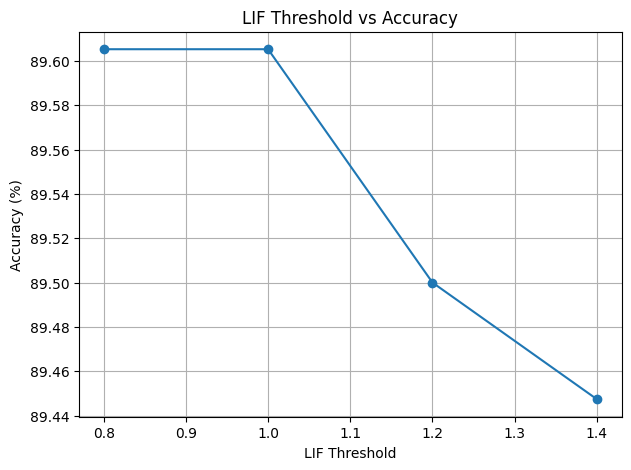

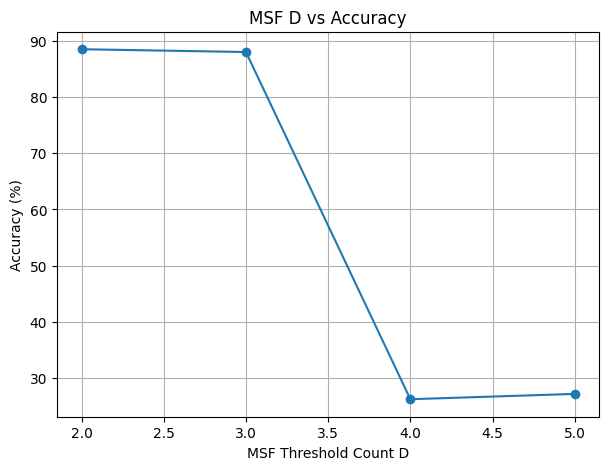

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from datasets import load_dataset
from collections import Counter
import matplotlib.pyplot as plt

# =========================================================
# DEVICE
# =========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================================================
# DATA
# =========================================================

dataset = load_dataset("ag_news")

train_data = dataset["train"]
test_data = dataset["test"]

# =========================================================
# TOKENIZER
# =========================================================

def tokenize(text):
    return text.lower().split()

# =========================================================
# VOCAB
# =========================================================

counter = Counter()

for sample in train_data:
    counter.update(tokenize(sample["text"]))

vocab = {"<pad>": 0, "<unk>": 1}

for word, freq in counter.items():
    if freq >= 5:
        vocab[word] = len(vocab)

vocab_size = len(vocab)

# =========================================================
# ENCODING
# =========================================================

max_len = 40

def encode_text(text):

    tokens = tokenize(text)

    ids = [vocab.get(token, 1) for token in tokens[:max_len]]

    if len(ids) < max_len:
        ids += [0] * (max_len - len(ids))

    return torch.tensor(ids)

# =========================================================
# DATASET
# =========================================================

class AGNewsDataset(torch.utils.data.Dataset):

    def __init__(self, split):
        self.data = split

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return encode_text(self.data[idx]["text"]), self.data[idx]["label"]

train_dataset = AGNewsDataset(train_data)
test_dataset = AGNewsDataset(test_data)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

# =========================================================
# SURROGATE
# =========================================================

class SpikeFunction(torch.autograd.Function):

    @staticmethod
    def forward(ctx, mem, threshold):
        ctx.save_for_backward(mem)
        return (mem >= threshold).float()

    @staticmethod
    def backward(ctx, grad_output):
        mem, = ctx.saved_tensors
        surrogate = torch.clamp(1 - torch.abs(mem), min=0)
        return grad_output * surrogate, None

# =========================================================
# LIF
# =========================================================

class LIFLayer(nn.Module):

    def __init__(self, input_size, output_size, threshold=1.0):
        super().__init__()
        self.fc = nn.Linear(input_size, output_size)
        self.threshold = threshold

    def forward(self, x, mem):

        mem = 0.9 * mem + self.fc(x)

        spike = SpikeFunction.apply(mem, self.threshold)

        mem = mem * (1 - spike)

        return spike, mem

# =========================================================
# MSF
# =========================================================

class MSFLayer(nn.Module):

    def __init__(self, input_size, output_size, D=3):
        super().__init__()
        self.fc = nn.Linear(input_size, output_size)
        self.thresholds = torch.arange(1, D + 1).float().to(device)

    def forward(self, x, mem):

        mem = 0.9 * mem + self.fc(x)

        total_spike = torch.zeros_like(mem)

        for th in self.thresholds:
            total_spike += SpikeFunction.apply(mem, th)

        mem = mem - total_spike
        mem = torch.clamp(mem, min=0)

        return total_spike, mem

# =========================================================
# MODEL
# =========================================================

class TemporalModel(nn.Module):

    def __init__(self, neuron="lif", threshold=1.0, D=3):
        super().__init__()

        embed_dim = 128
        self.hidden_dim = 512

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        if neuron == "lif":
            self.layer1 = LIFLayer(embed_dim, self.hidden_dim, threshold)
            self.layer2 = LIFLayer(self.hidden_dim, 4, threshold)
        else:
            self.layer1 = MSFLayer(embed_dim, self.hidden_dim, D)
            self.layer2 = MSFLayer(self.hidden_dim, 4, D)

    def forward(self, x):

        x = self.embedding(x)

        batch = x.size(0)
        seq_len = x.size(1)

        mem1 = torch.zeros(batch, self.hidden_dim).to(device)
        mem2 = torch.zeros(batch, 4).to(device)

        out = torch.zeros(batch, 4).to(device)

        for t in range(seq_len):

            token = x[:, t, :]

            spk1, mem1 = self.layer1(token, mem1)
            spk2, mem2 = self.layer2(spk1, mem2)

            out += spk2

        return out / seq_len

# =========================================================
# TRAIN + TEST
# =========================================================

def train_and_test(model, epochs=3):

    optimizer = optim.Adam(model.parameters(), lr=5e-4)
    criterion = nn.CrossEntropyLoss()

    model.train()

    for epoch in range(epochs):

        for text, label in train_loader:

            text = text.to(device)
            label = label.to(device)

            optimizer.zero_grad()

            output = model(text)

            loss = criterion(output, label)

            loss.backward()

            optimizer.step()

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for text, label in test_loader:

            text = text.to(device)
            label = label.to(device)

            output = model(text)

            pred = output.argmax(dim=1)

            correct += (pred == label).sum().item()
            total += label.size(0)

    return 100 * correct / total

# =========================================================
# EXPERIMENT 1 : LIF THRESHOLD SWEEP
# =========================================================

lif_thresholds = [0.8, 1.0, 1.2, 1.4]
lif_acc = []

print("\n===== LIF Threshold Sweep =====")

for th in lif_thresholds:

    model = TemporalModel("lif", threshold=th).to(device)

    acc = train_and_test(model)

    lif_acc.append(acc)

    print(f"Threshold {th}: {acc:.2f}%")

# =========================================================
# EXPERIMENT 2 : MSF D SWEEP
# =========================================================

msf_D = [2, 3, 4, 5]
msf_acc = []

print("\n===== MSF D Sweep =====")

for d in msf_D:

    model = TemporalModel("msf", D=d).to(device)

    acc = train_and_test(model)

    msf_acc.append(acc)

    print(f"D={d}: {acc:.2f}%")

# =========================================================
# PLOT 1 : LIF
# =========================================================

plt.figure(figsize=(7,5))
plt.plot(lif_thresholds, lif_acc, marker='o')
plt.xlabel("LIF Threshold")
plt.ylabel("Accuracy (%)")
plt.title("LIF Threshold vs Accuracy")
plt.grid(True)
plt.show()

# =========================================================
# PLOT 2 : MSF
# =========================================================

plt.figure(figsize=(7,5))
plt.plot(msf_D, msf_acc, marker='o')
plt.xlabel("MSF Threshold Count D")
plt.ylabel("Accuracy (%)")
plt.title("MSF D vs Accuracy")
plt.grid(True)
plt.show()

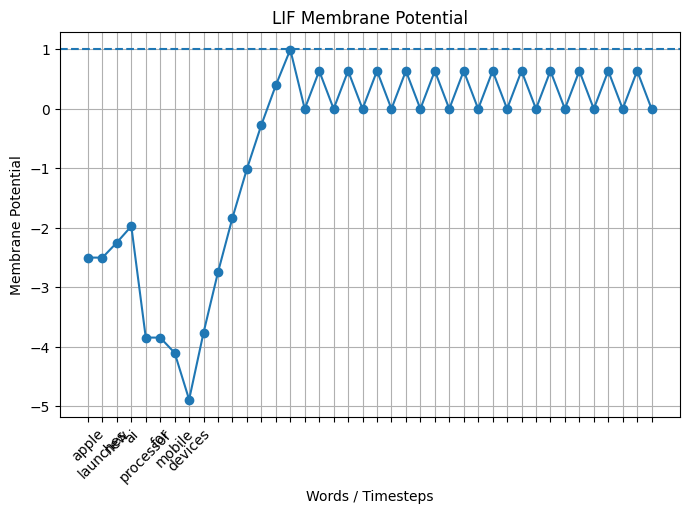

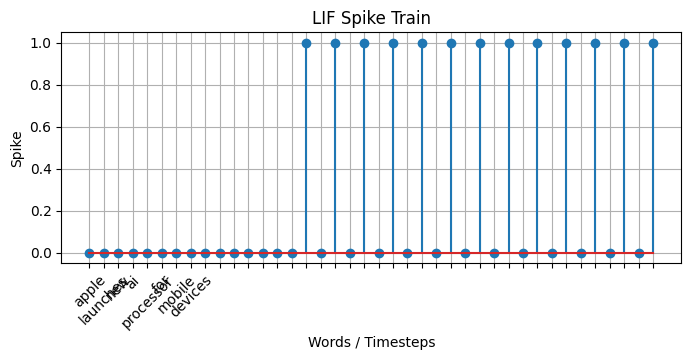

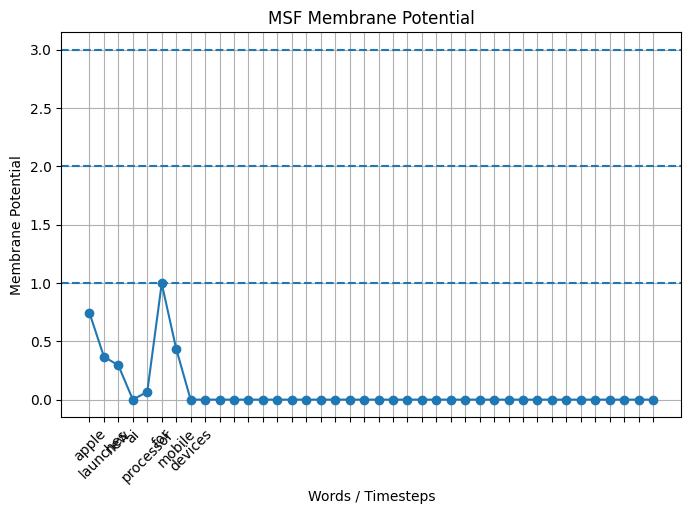

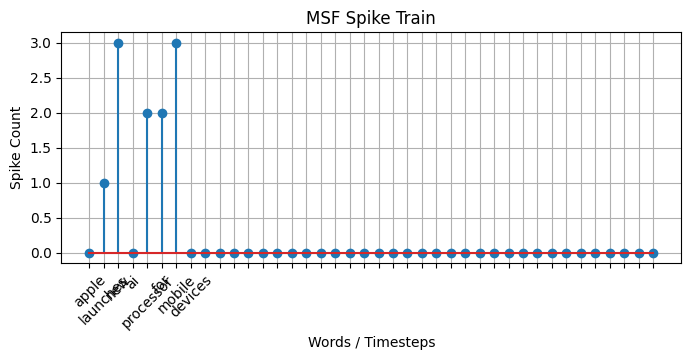

In [5]:
import matplotlib.pyplot as plt

# =========================================================
# SELECT ONE ARTICLE
# =========================================================

sample_text = "Apple launches new AI processor for mobile devices"

tokens = tokenize(sample_text)

encoded = encode_text(sample_text).unsqueeze(0).to(device)

# =========================================================
# GET EMBEDDING
# =========================================================

embedding = lif_model.embedding(encoded)

seq_len = embedding.size(1)

# =========================================================
# TRACK LIF
# =========================================================

lif_mem = torch.zeros(1, lif_model.hidden_dim).to(device)

lif_mem_trace = []
lif_spike_trace = []

for t in range(seq_len):

    token = embedding[:, t, :]

    spk, lif_mem = lif_model.layer1(token, lif_mem)

    # track first neuron only
    lif_mem_trace.append(lif_mem[0,0].item())
    lif_spike_trace.append(spk[0,0].item())

# =========================================================
# TRACK MSF
# =========================================================

msf_mem = torch.zeros(1, msf_model.hidden_dim).to(device)

msf_mem_trace = []
msf_spike_trace = []

for t in range(seq_len):

    token = embedding[:, t, :]

    spk, msf_mem = msf_model.layer1(token, msf_mem)

    msf_mem_trace.append(msf_mem[0,0].item())
    msf_spike_trace.append(spk[0,0].item())

# =========================================================
# PLOT LIF MEMBRANE
# =========================================================

plt.figure(figsize=(8,5))
plt.plot(range(seq_len), lif_mem_trace, marker='o')
plt.axhline(y=1.0, linestyle='--')
plt.xticks(range(seq_len), tokens + [""]*(seq_len-len(tokens)), rotation=45)
plt.xlabel("Words / Timesteps")
plt.ylabel("Membrane Potential")
plt.title("LIF Membrane Potential")
plt.grid(True)
plt.show()

# =========================================================
# PLOT LIF SPIKES
# =========================================================

plt.figure(figsize=(8,3))
plt.stem(range(seq_len), lif_spike_trace)
plt.xticks(range(seq_len), tokens + [""]*(seq_len-len(tokens)), rotation=45)
plt.xlabel("Words / Timesteps")
plt.ylabel("Spike")
plt.title("LIF Spike Train")
plt.grid(True)
plt.show()

# =========================================================
# PLOT MSF MEMBRANE
# =========================================================

plt.figure(figsize=(8,5))
plt.plot(range(seq_len), msf_mem_trace, marker='o')
plt.axhline(y=1.0, linestyle='--')
plt.axhline(y=2.0, linestyle='--')
plt.axhline(y=3.0, linestyle='--')
plt.xticks(range(seq_len), tokens + [""]*(seq_len-len(tokens)), rotation=45)
plt.xlabel("Words / Timesteps")
plt.ylabel("Membrane Potential")
plt.title("MSF Membrane Potential")
plt.grid(True)
plt.show()

# =========================================================
# PLOT MSF SPIKES
# =========================================================

plt.figure(figsize=(8,3))
plt.stem(range(seq_len), msf_spike_trace)
plt.xticks(range(seq_len), tokens + [""]*(seq_len-len(tokens)), rotation=45)
plt.xlabel("Words / Timesteps")
plt.ylabel("Spike Count")
plt.title("MSF Spike Train")
plt.grid(True)
plt.show()

In [6]:
# =========================================================
# LABEL MAP
# =========================================================

label_names = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

# =========================================================
# SELECT ONE TEST ARTICLE
# =========================================================

sample_idx = 25   # you can change this index

sample_text = test_data[sample_idx]["text"]
true_label = test_data[sample_idx]["label"]

print("\n===== ARTICLE =====")
print(sample_text)

print("\nTrue Label:")
print(label_names[true_label])

# =========================================================
# ENCODE INPUT
# =========================================================

encoded = encode_text(sample_text).unsqueeze(0).to(device)

# =========================================================
# LIF PREDICTION
# =========================================================

lif_model.eval()

with torch.no_grad():

    lif_output = lif_model(encoded)

    lif_pred = lif_output.argmax(dim=1).item()

print("\n===== LIF Prediction =====")
print("Predicted Label:", label_names[lif_pred])

print("Raw Output Scores:")
print(lif_output.cpu().numpy())

# =========================================================
# MSF PREDICTION
# =========================================================

msf_model.eval()

with torch.no_grad():

    msf_output = msf_model(encoded)

    msf_pred = msf_output.argmax(dim=1).item()

print("\n===== MSF Prediction =====")
print("Predicted Label:", label_names[msf_pred])

print("Raw Output Scores:")
print(msf_output.cpu().numpy())


===== ARTICLE =====
News: Sluggish movement on power grid cyber security Industry cyber security standards fail to reach some of the most vulnerable components of the power grid.\

True Label:
Sci/Tech

===== LIF Prediction =====
Predicted Label: Sci/Tech
Raw Output Scores:
[[0.025 0.    0.    0.825]]

===== MSF Prediction =====
Predicted Label: Sci/Tech
Raw Output Scores:
[[0.45000002 0.         0.22500001 2.8500001 ]]


In [7]:
# =========================================================
# LABEL MAP
# =========================================================

label_names = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

# =========================================================
# FIND DISAGREEMENTS
# =========================================================

lif_correct_msf_wrong = []
msf_correct_lif_wrong = []

lif_model.eval()
msf_model.eval()

with torch.no_grad():

    for i in range(len(test_data)):

        text = test_data[i]["text"]
        true_label = test_data[i]["label"]

        encoded = encode_text(text).unsqueeze(0).to(device)

        # LIF prediction
        lif_out = lif_model(encoded)
        lif_pred = lif_out.argmax(dim=1).item()

        # MSF prediction
        msf_out = msf_model(encoded)
        msf_pred = msf_out.argmax(dim=1).item()

        # Case 1: LIF correct, MSF wrong
        if lif_pred == true_label and msf_pred != true_label:
            lif_correct_msf_wrong.append((text, true_label, lif_pred, msf_pred))

        # Case 2: MSF correct, LIF wrong
        if msf_pred == true_label and lif_pred != true_label:
            msf_correct_lif_wrong.append((text, true_label, lif_pred, msf_pred))

        # stop after finding enough examples
        if len(lif_correct_msf_wrong) >= 3 and len(msf_correct_lif_wrong) >= 3:
            break

# =========================================================
# PRINT CASE 1
# =========================================================

print("\n===== LIF CORRECT / MSF WRONG =====")

for sample in lif_correct_msf_wrong:

    text, true_label, lif_pred, msf_pred = sample

    print("\nArticle:")
    print(text)

    print("True Label:", label_names[true_label])
    print("LIF Prediction:", label_names[lif_pred])
    print("MSF Prediction:", label_names[msf_pred])

# =========================================================
# PRINT CASE 2
# =========================================================

print("\n===== MSF CORRECT / LIF WRONG =====")

for sample in msf_correct_lif_wrong:

    text, true_label, lif_pred, msf_pred = sample

    print("\nArticle:")
    print(text)

    print("True Label:", label_names[true_label])
    print("LIF Prediction:", label_names[lif_pred])
    print("MSF Prediction:", label_names[msf_pred])


===== LIF CORRECT / MSF WRONG =====

Article:
E-mail scam targets police chief Wiltshire Police warns about "phishing" after its fraud squad chief was targeted.
True Label: Sci/Tech
LIF Prediction: Sci/Tech
MSF Prediction: Business

Article:
Teenage T. rex's monster growth Tyrannosaurus rex achieved its massive size due to an enormous growth spurt during its adolescent years.
True Label: Sci/Tech
LIF Prediction: Sci/Tech
MSF Prediction: Business

Article:
Some People Not Eligible to Get in on Google IPO Google has billed its IPO as a way for everyday people to get in on the process, denying Wall Street the usual stranglehold it's had on IPOs. Public bidding, a minimum of just five shares, an open process with 28 underwriters - all this pointed to a new level of public participation. But this isn't the case.
True Label: Sci/Tech
LIF Prediction: Sci/Tech
MSF Prediction: Business

Article:
Venezuela Prepares for Chavez Recall Vote Supporters and rivals warn of possible fraud; government 